# GLobal Clustering

*Date: 14 July, 2026 - BY: Tomás Silva*

### Imports & Setting up the notebook

In [8]:
import pandas as pd
import numpy as np
import os
import glob
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import hdbscan

### Import data and Stack it into a master table

In [5]:
def load_all_samples(clean_data_folder='Data-cleaned'):
    all_files = glob.glob(os.path.join(clean_data_folder, "*IQ_cleaned.csv"))
    
    if len(all_files) == 0:
        print("No cleaned CSVs found. Check your folder path!")
        return None
        
    print(f"Found {len(all_files)} cleaned samples. Stacking...")
    
    combined_data = []
    for file in all_files:
        df = pd.read_csv(file)
        combined_data.append(df)
        
    # Stack all 18 samples into one giant dataframe
    df_master = pd.concat(combined_data, ignore_index=True)
    print(f"Successfully stacked! Master dataset has {len(df_master)} data points.")
    
    return df_master

# Run the loader
df_master = load_all_samples()
display(df_master.info())

Found 18 cleaned samples. Stacking...
Successfully stacked! Master dataset has 88856 data points.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88856 entries, 0 to 88855
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   x                             88856 non-null  int64  
 1   y                             88856 non-null  int64  
 2   total SAXS intensity          88856 non-null  float64
 3   total_SAXS_norm_0_1           88856 non-null  float64
 4   area under third order curve  87616 non-null  float64
 5   collagen_third_norm_0_1       87616 non-null  float64
 6   percentage_above_baseline     87616 non-null  float64
 7   max_recorded_intensity        87616 non-null  float64
 8   firstmoment                   87546 non-null  float64
 9   secondmoment                  87546 non-null  float64
 10  thirdmoment                   87546 non-null  float64
 11  skewness             

None

### Normalisation

We cannot just stack the raw data because of batch effects (beamline intensity fluctuating between scans). To address this, we normalise each samples individually before we cluster them.

In [ ]:
# 1. Define the features choosen for clustering
features = [
    'D_period', 
    'wp', 
    'area under third order curve', 
    'peak_width', 
    'secondmoment_lu'
]

# 2. HDBSCAN cannot handle missing data. Drop rows where these fitting features failed (NaN)
print(f"Total points before cleanup: {len(df_master)}")
df_clustering = df_master.dropna(subset=features).copy()
print(f"Valid points ready for clustering: {len(df_clustering)}")

# 3. Extract just those features into a mathematical matrix (X)
X_raw = df_clustering[features].values

# 4. Normalize the 5 features from 0.0 to 1.0 so HDBSCAN treats them with equal weight
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_raw)

print("Matrix X_scaled is prepared for clustering!")

Total points before cleanup: 88856
Valid points ready for clustering: 87546
Matrix X_scaled is perfectly prepared for clustering!


### Run HDBSCAN

In [18]:
print("Running HDBSCAN...")

hdb_clusters = hdbscan.HDBSCAN(min_cluster_size=4000, min_samples=100)
# min_cluster_size=4000 & min_samples=100 -> 4 clusters + noise
# min_cluster_size=4000 & min_samples=10 -> 6 clusters + noise
hdb_labels = hdb_clusters.fit_predict(X_scaled)

# Attatch the cluster labels back to the original dataframe
df_clustering['cluster'] = hdb_labels

df_clustering.head(5)

cluster_counts = df_clustering['cluster'].value_counts().sort_index()

print("\nClustering Complete! Here is what it found:")
for cluster_id, count in cluster_counts.items():
    if cluster_id == -1:
        print(f"Cluster -1 (Noise/Artifacts): {count} pixels")
    else:
        print(f"Cluster {cluster_id}: {count} pixels")

Running HDBSCAN...

Clustering Complete! Here is what it found:
Cluster -1 (Noise/Artifacts): 45341 pixels
Cluster 0: 25462 pixels
Cluster 1: 5130 pixels
Cluster 2: 5277 pixels
Cluster 3: 6336 pixels


### Plotting

Generating mapping plots for 18 samples...



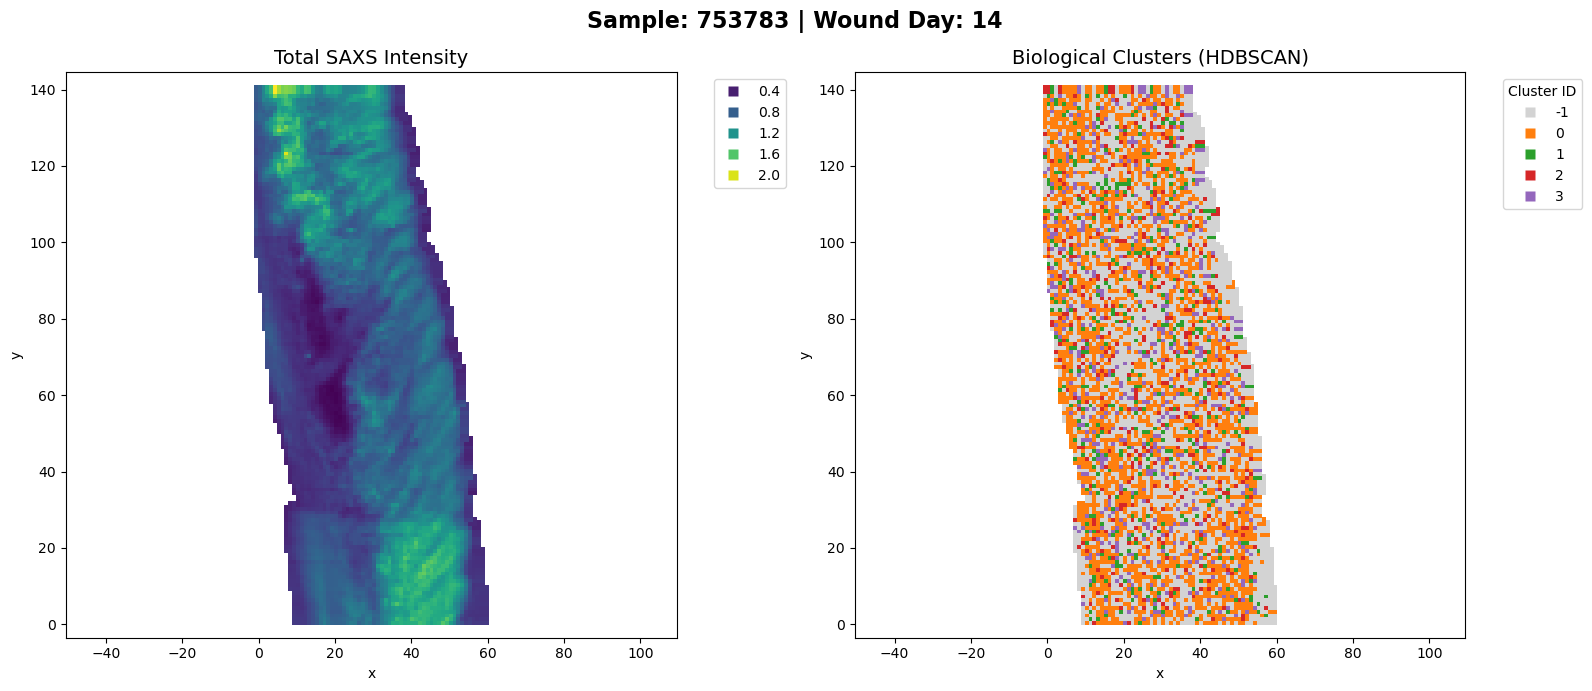

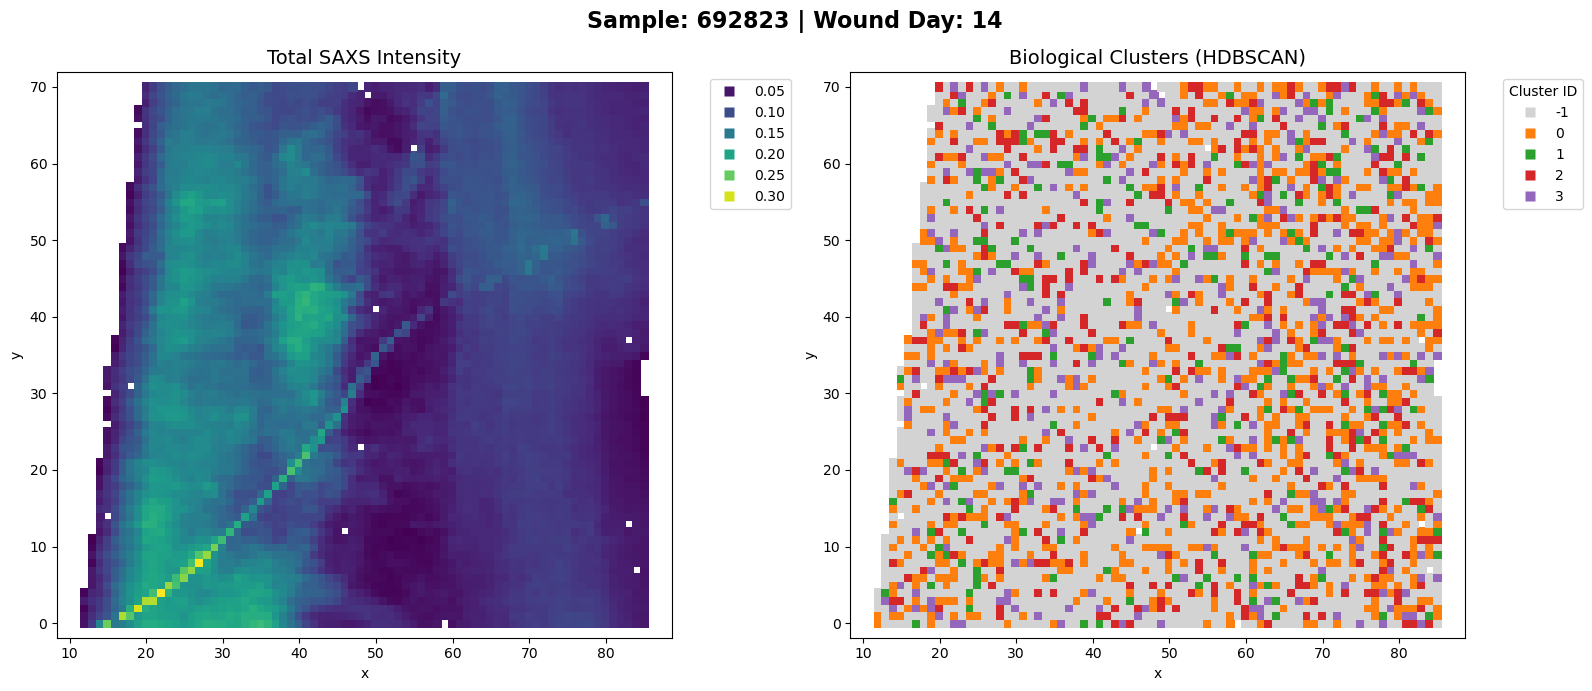

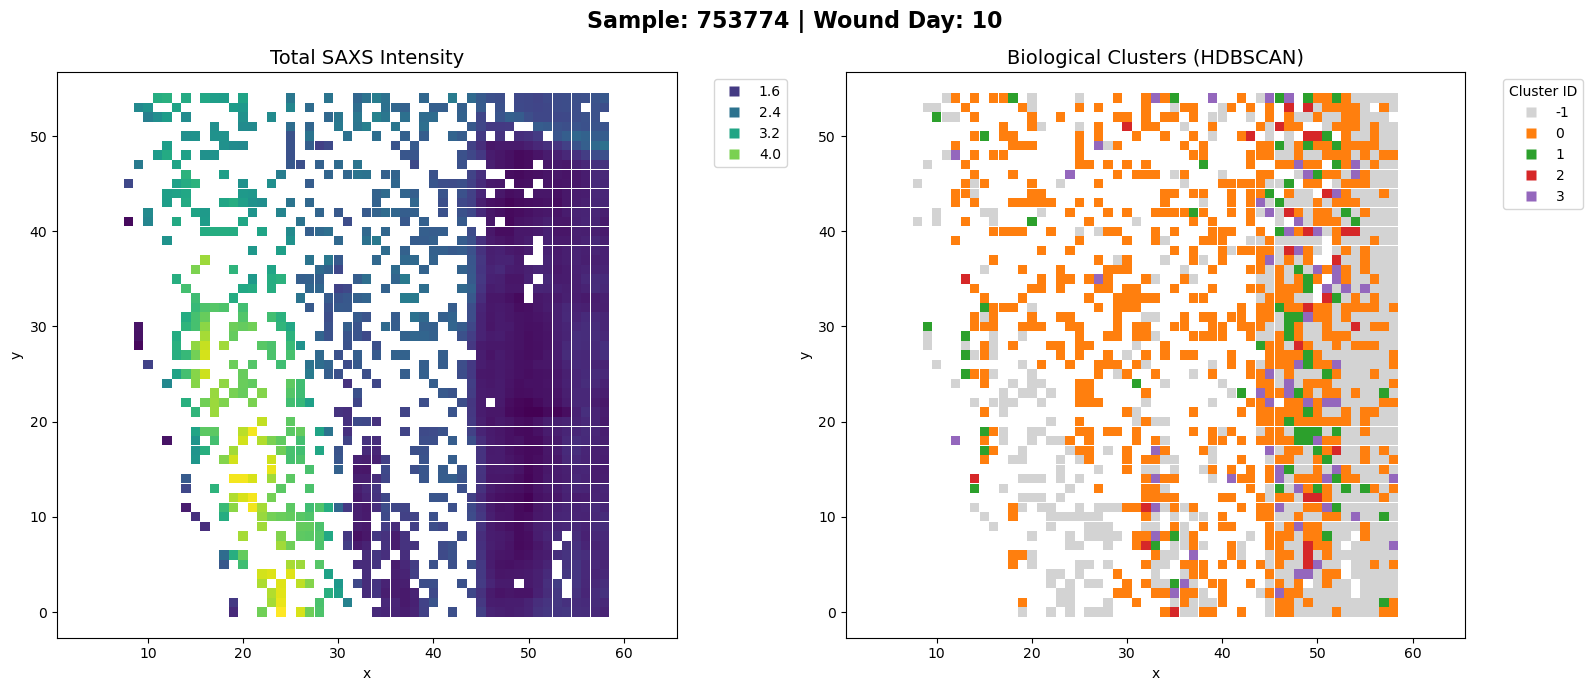

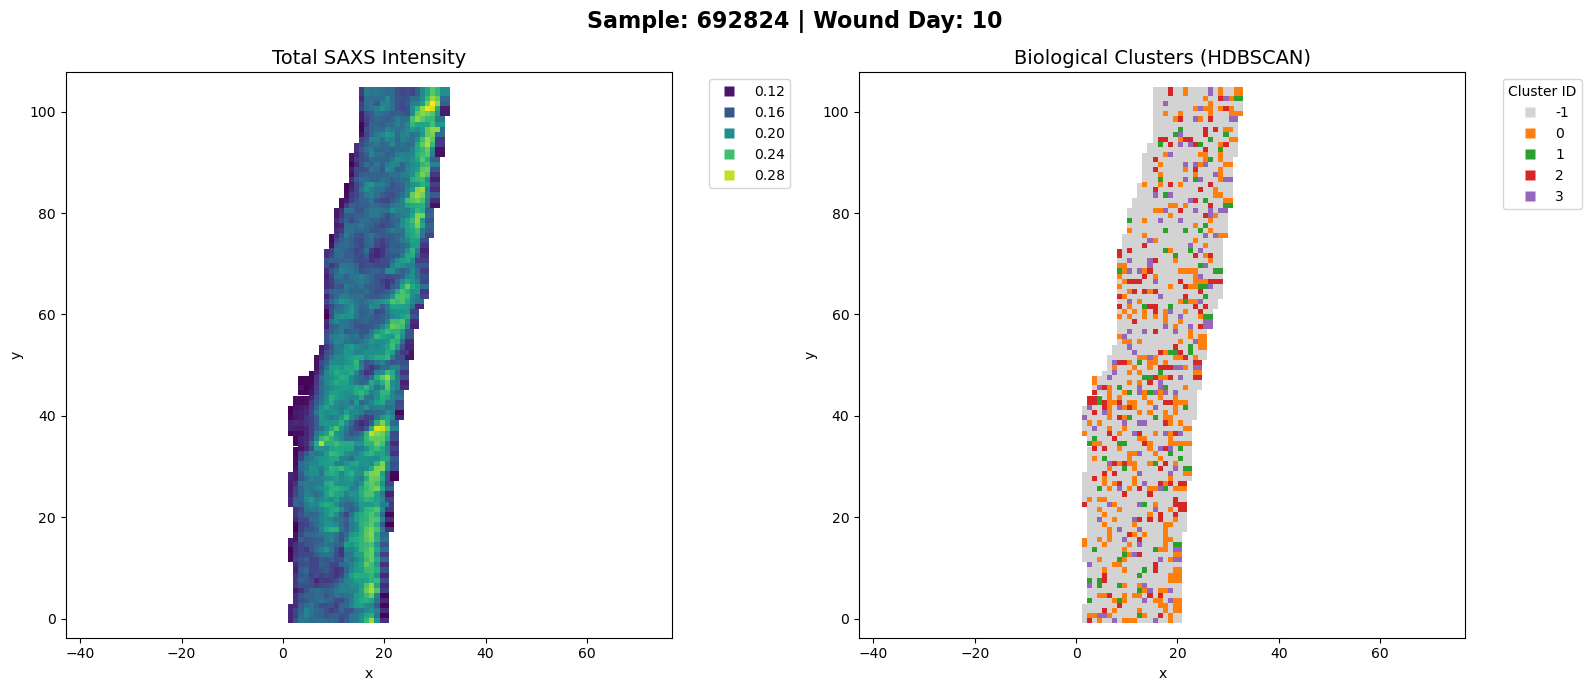

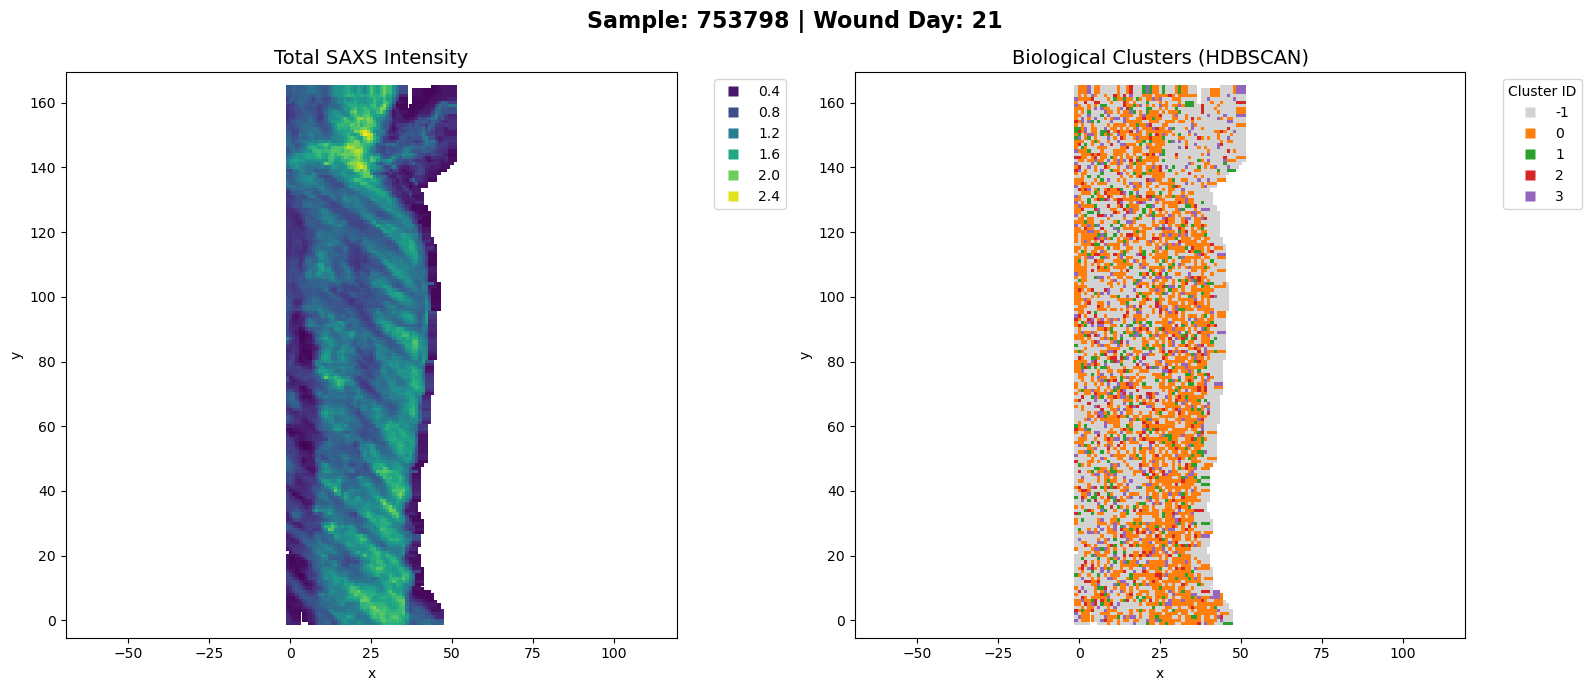

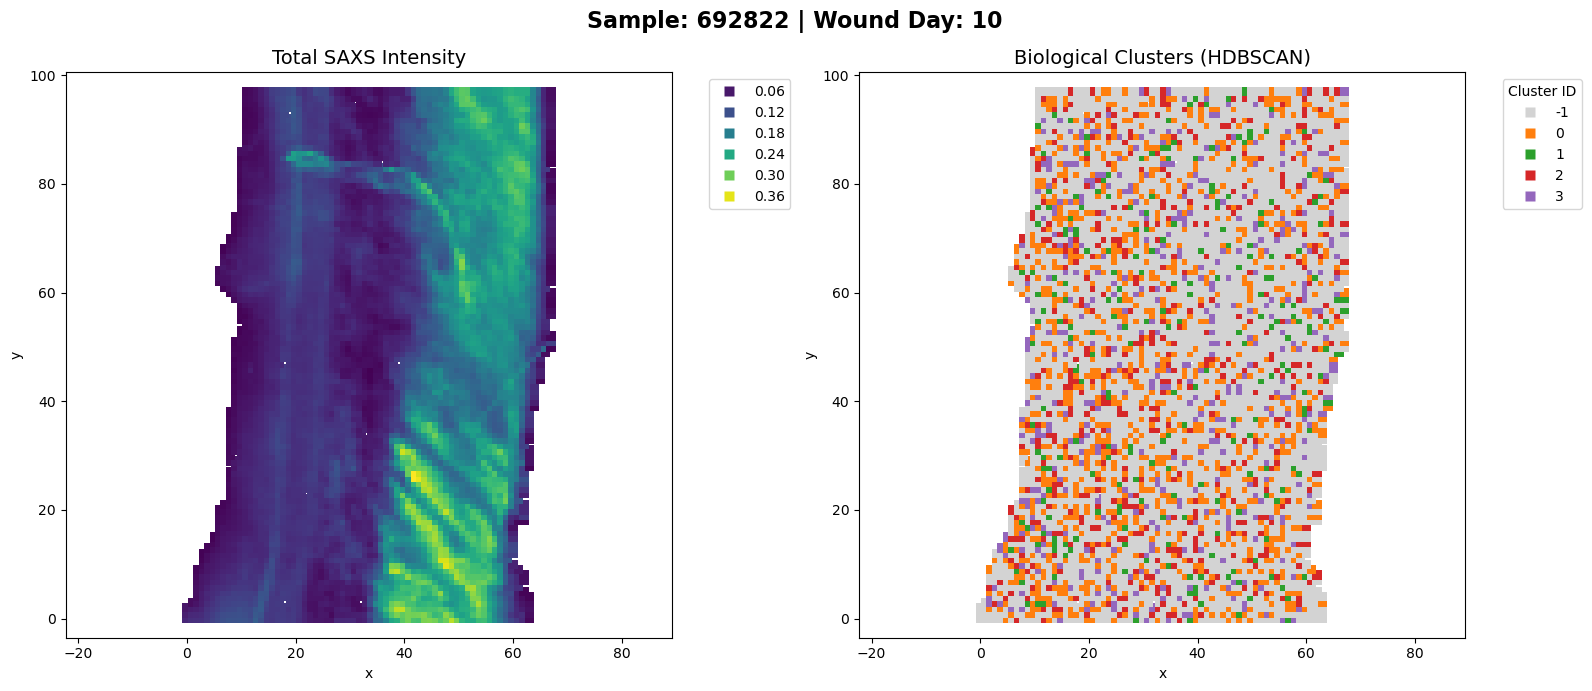

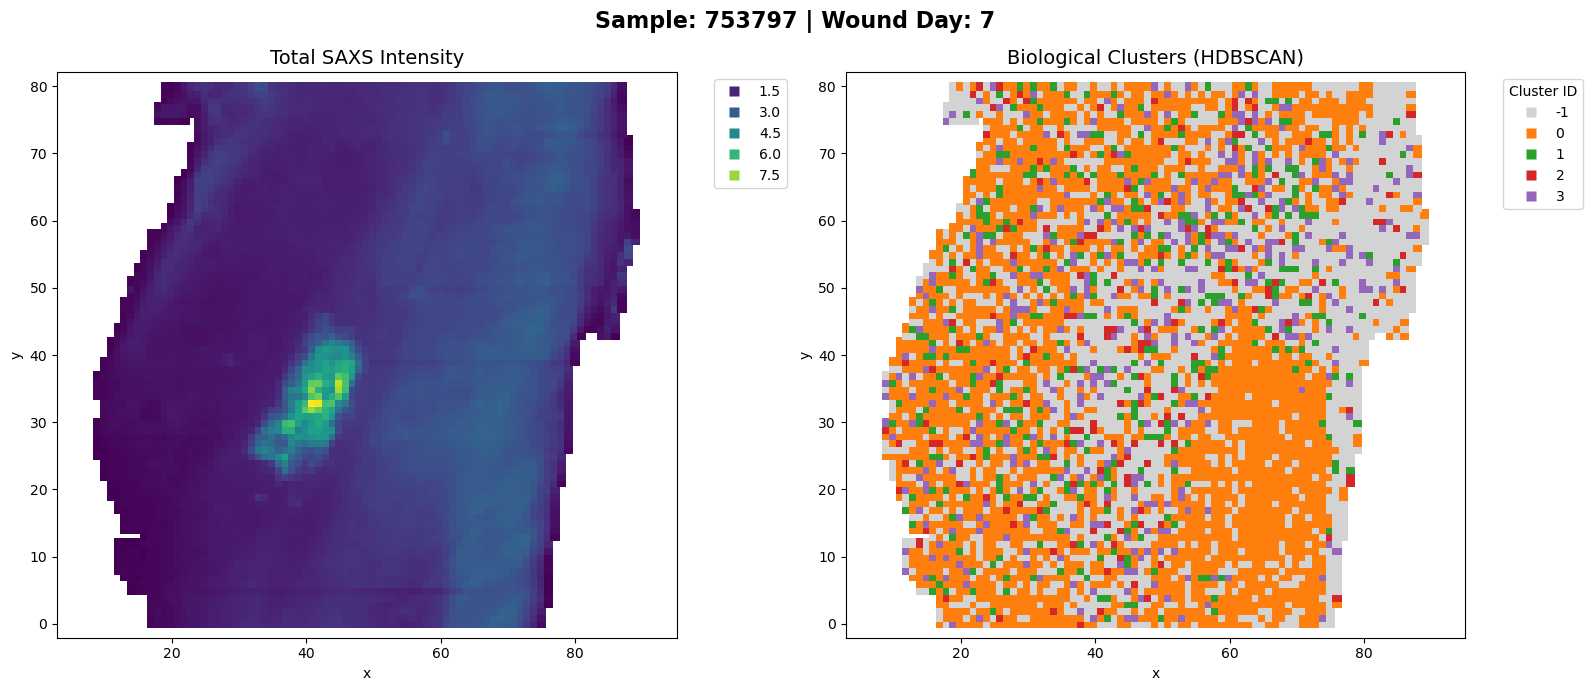

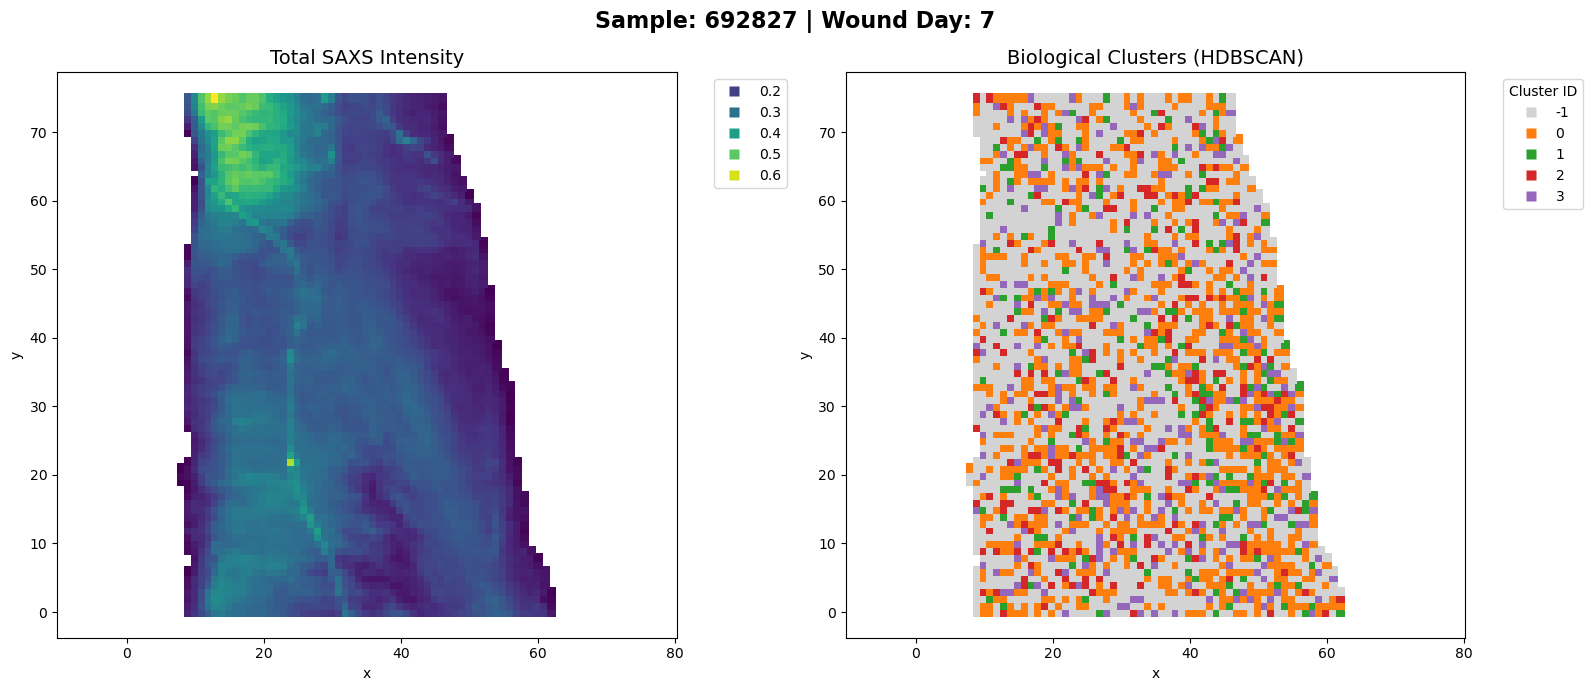

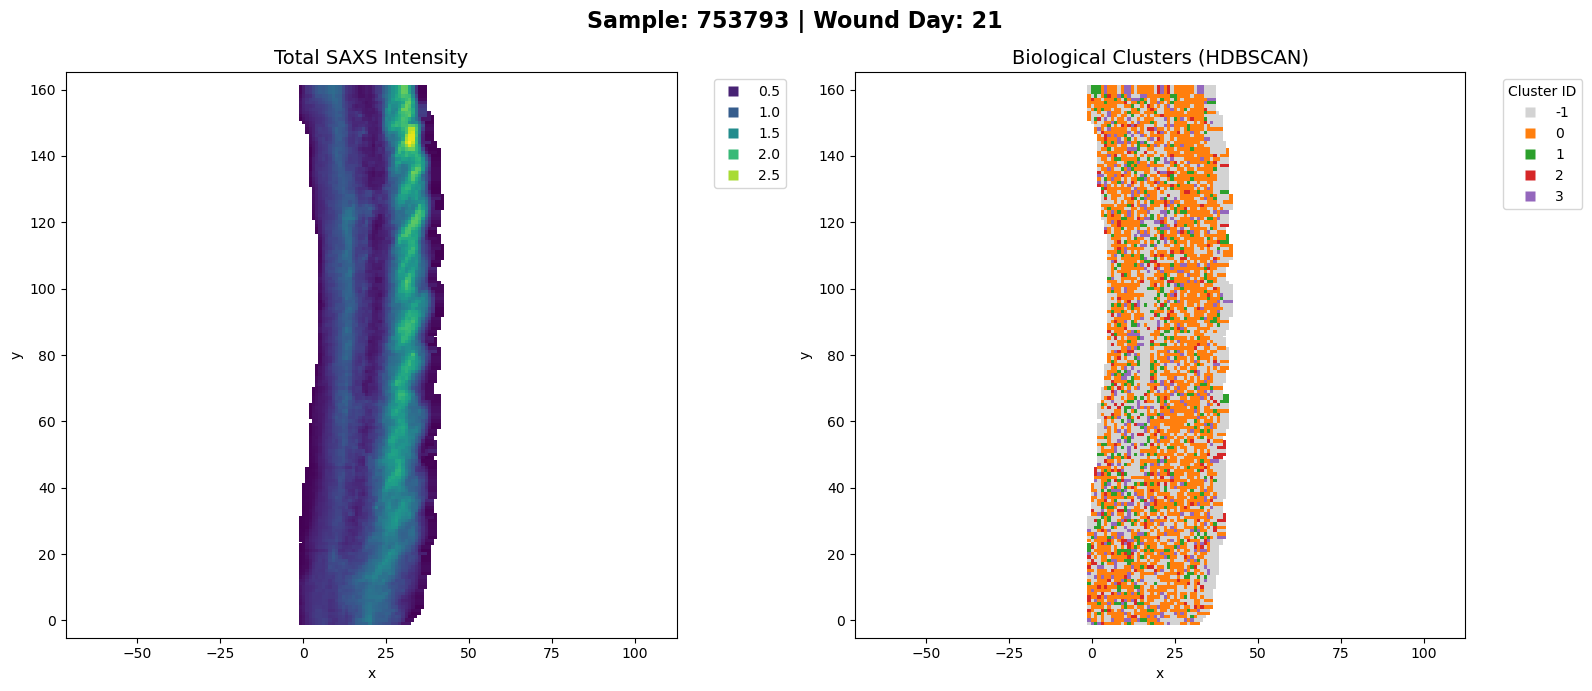

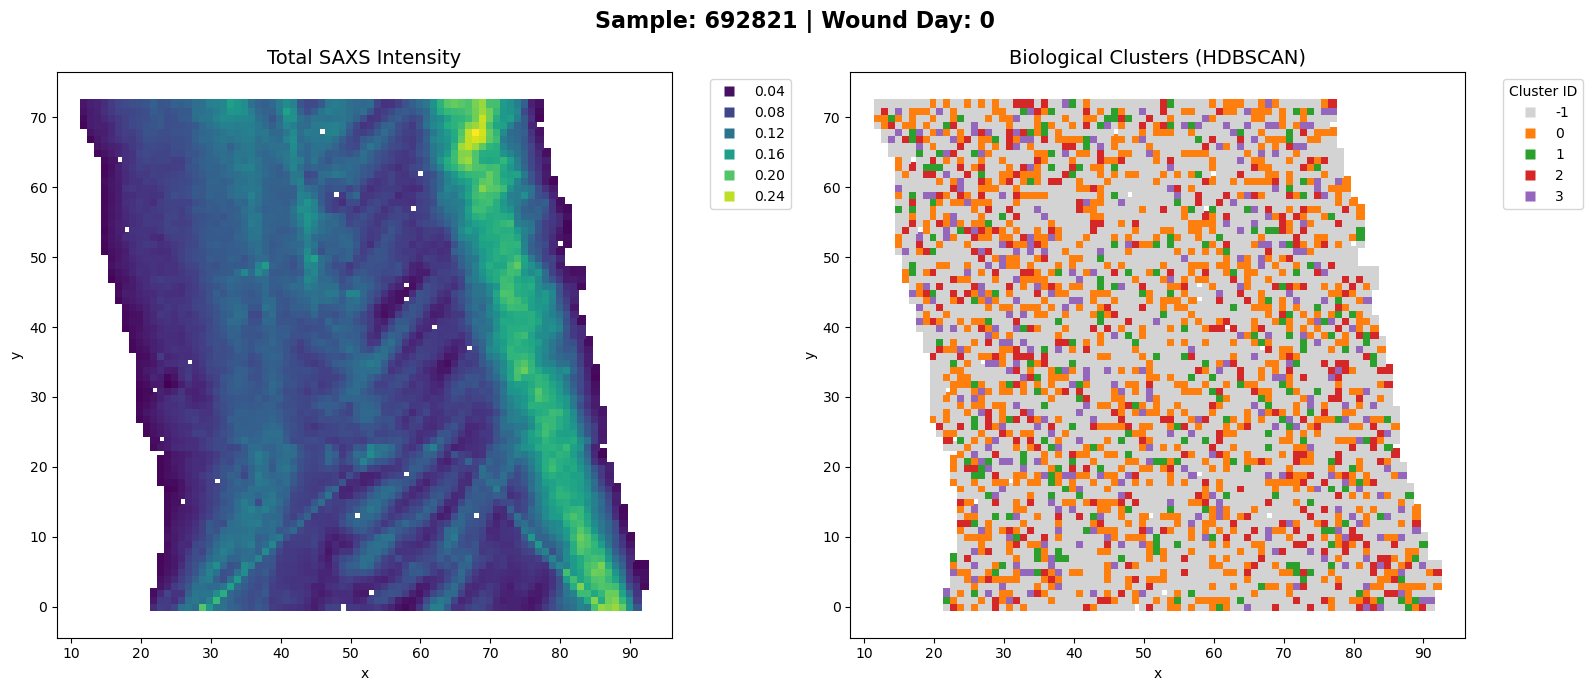

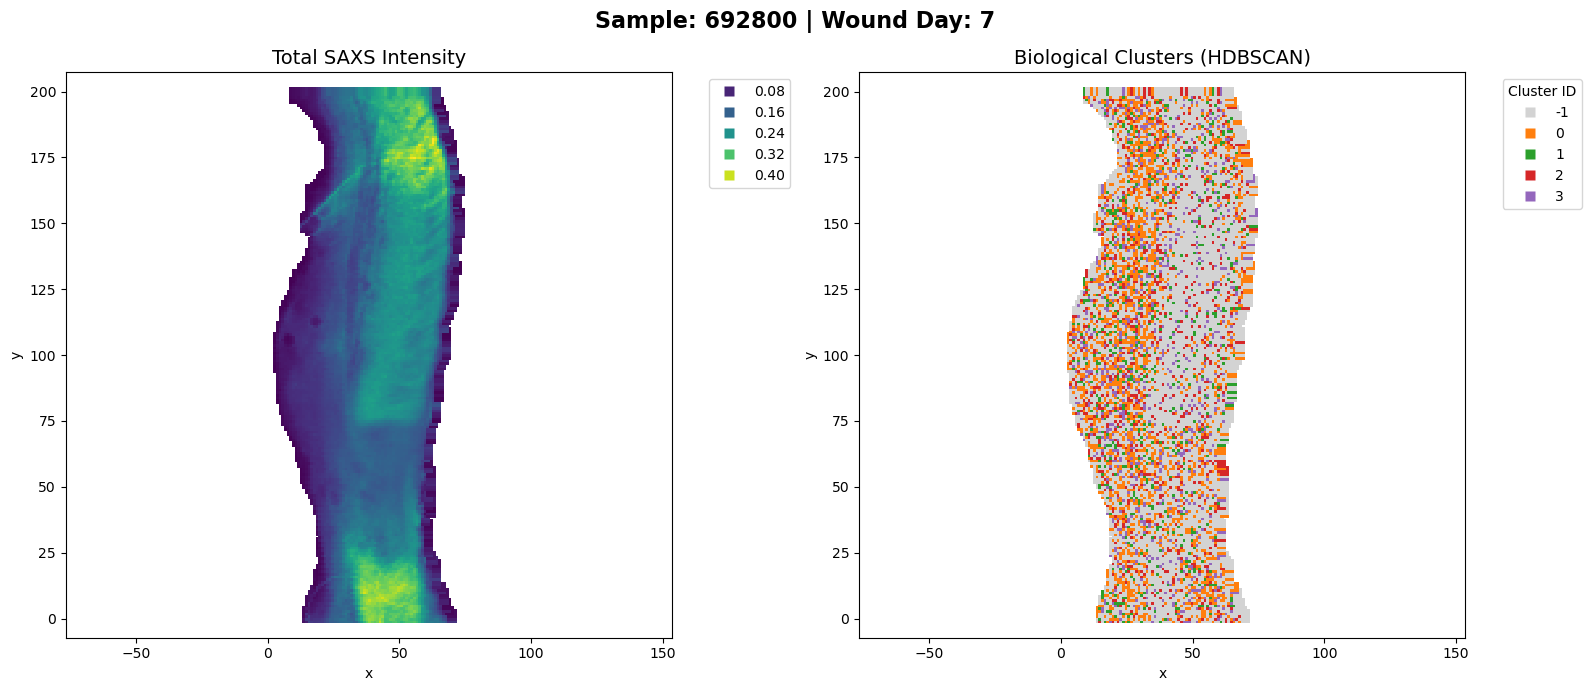

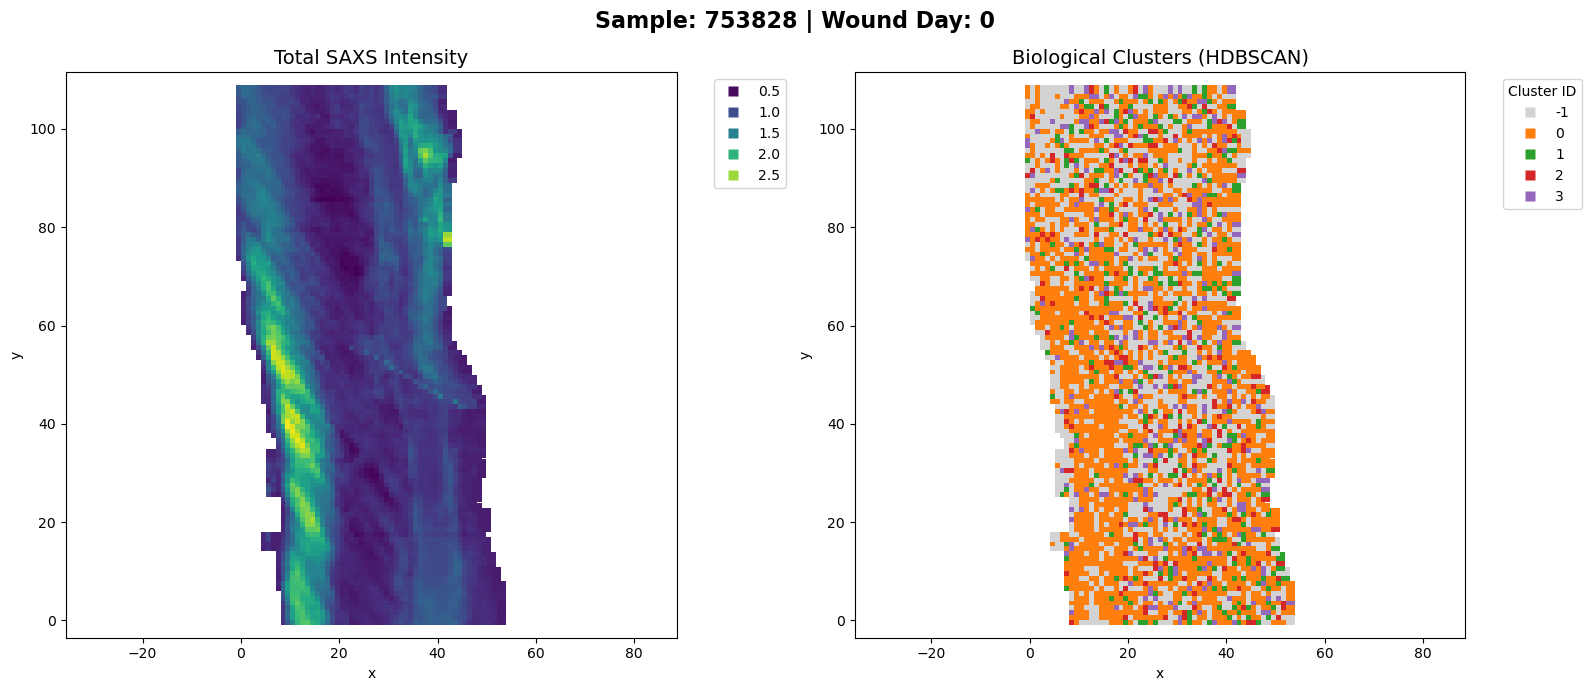

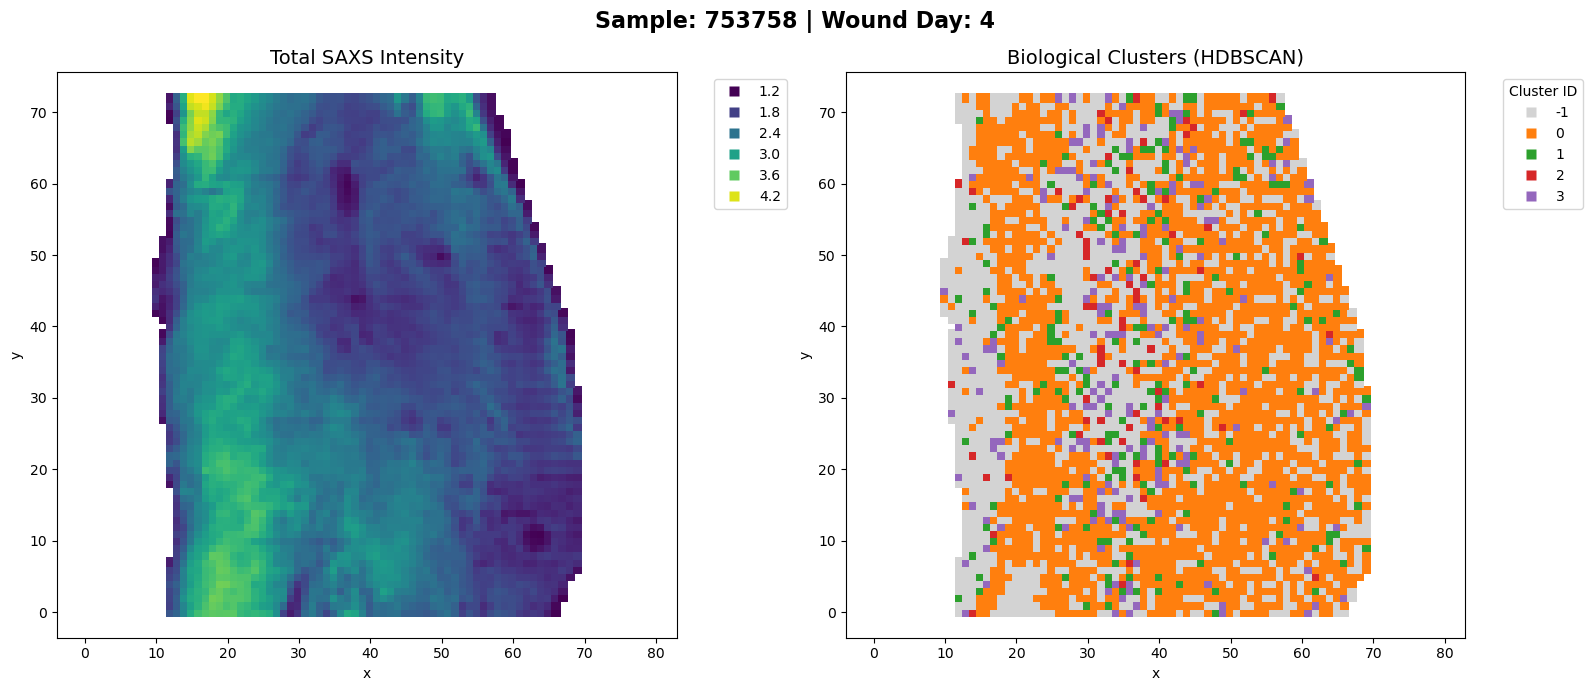

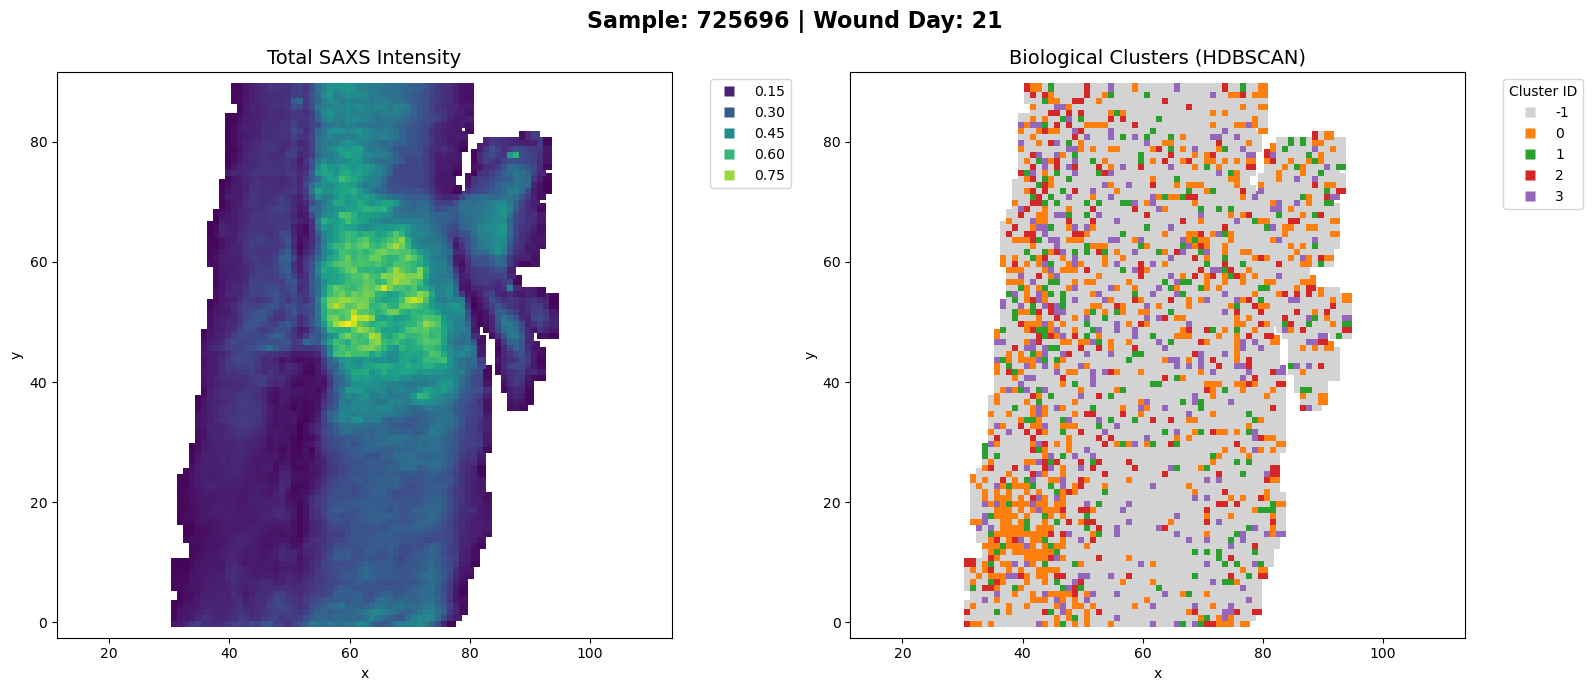

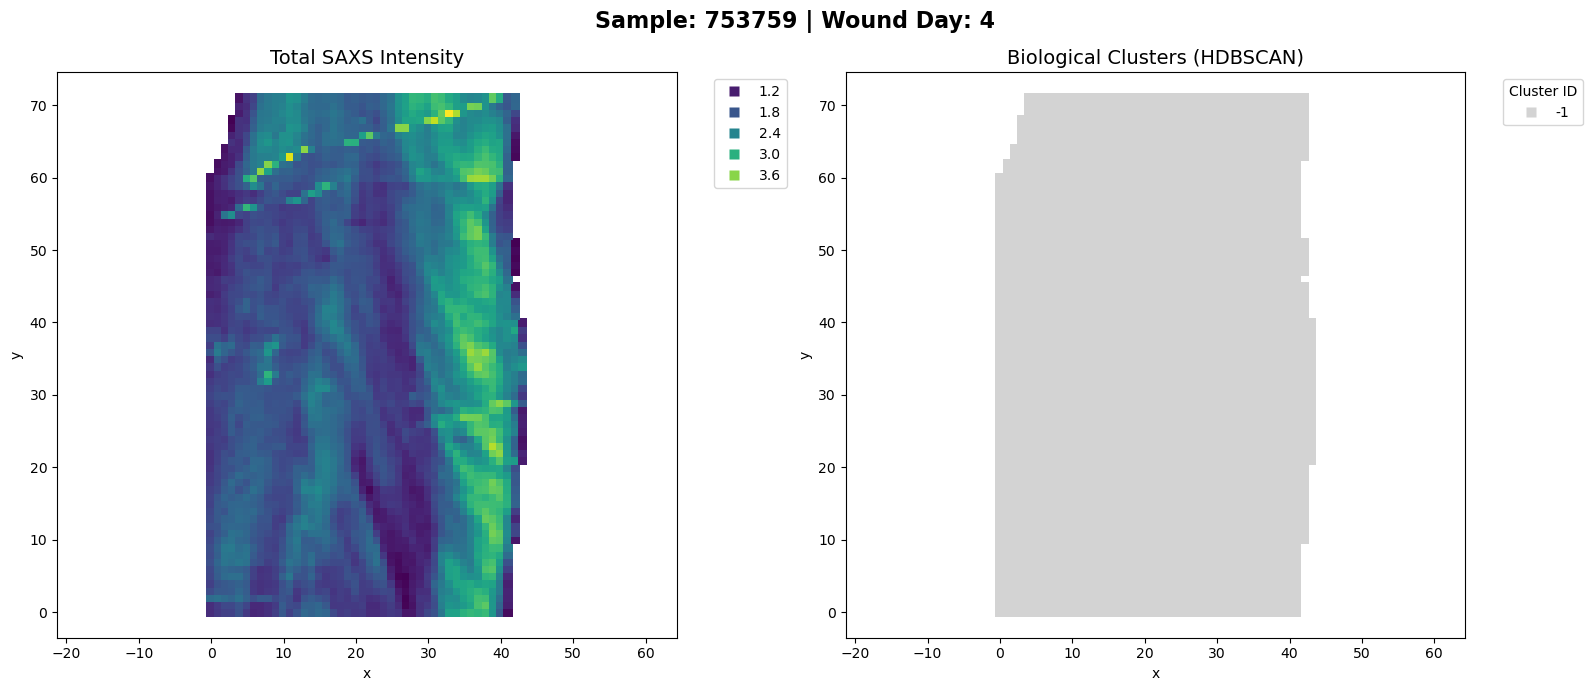

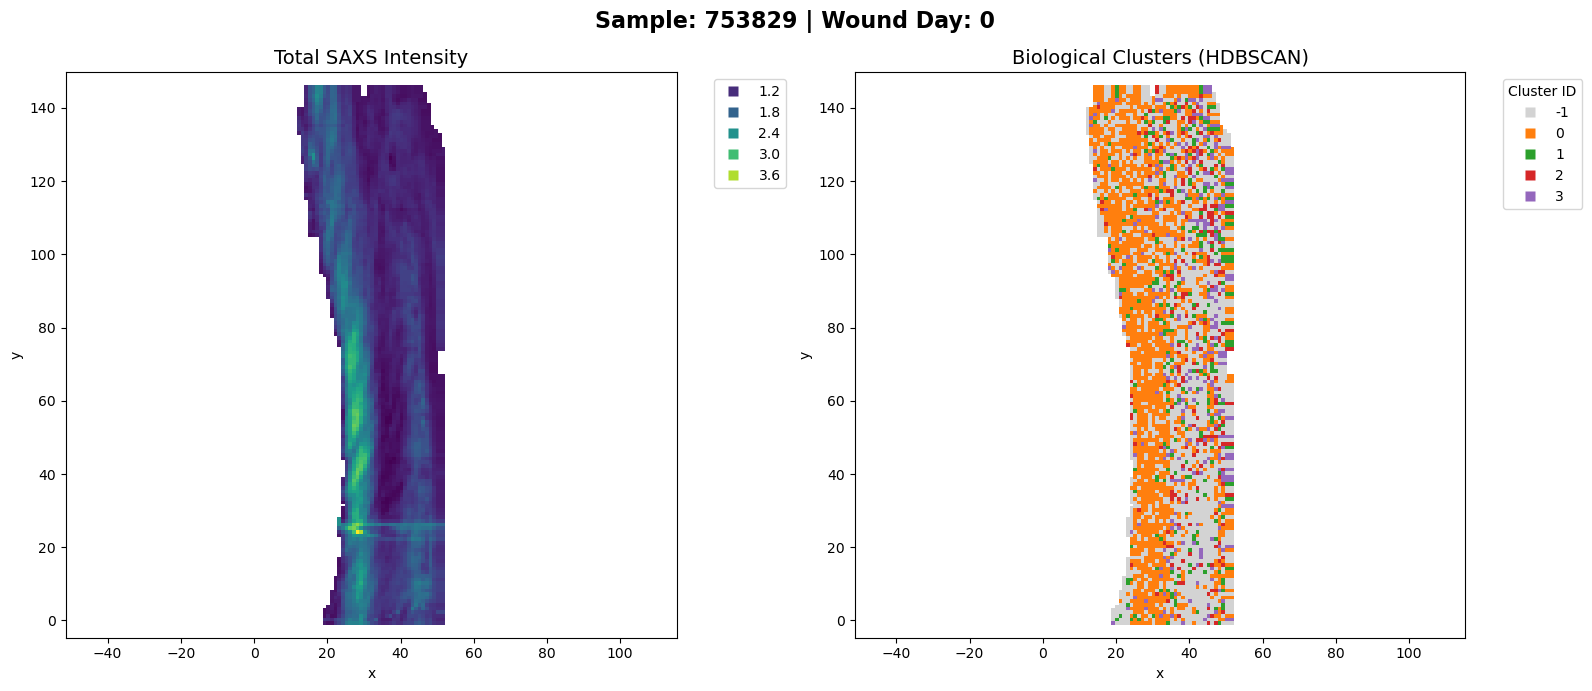

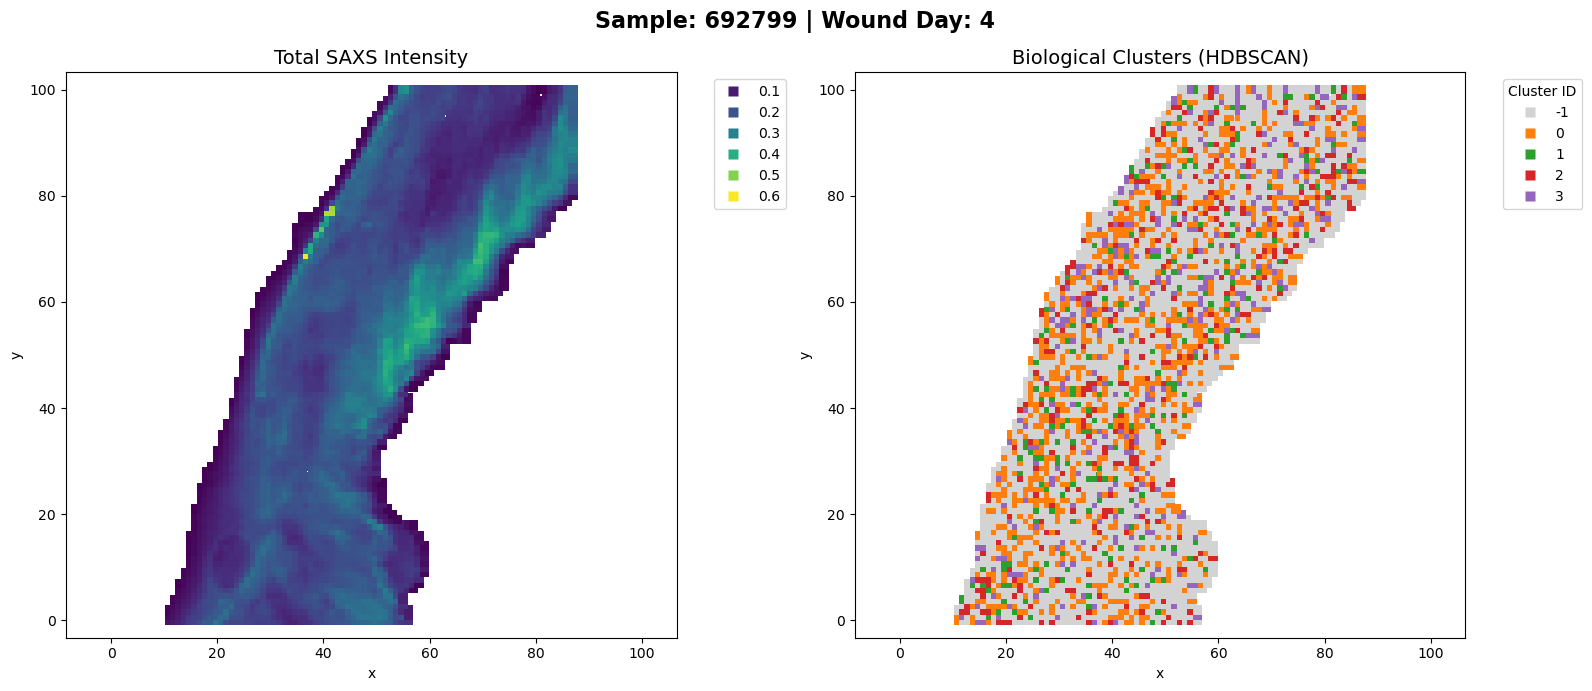

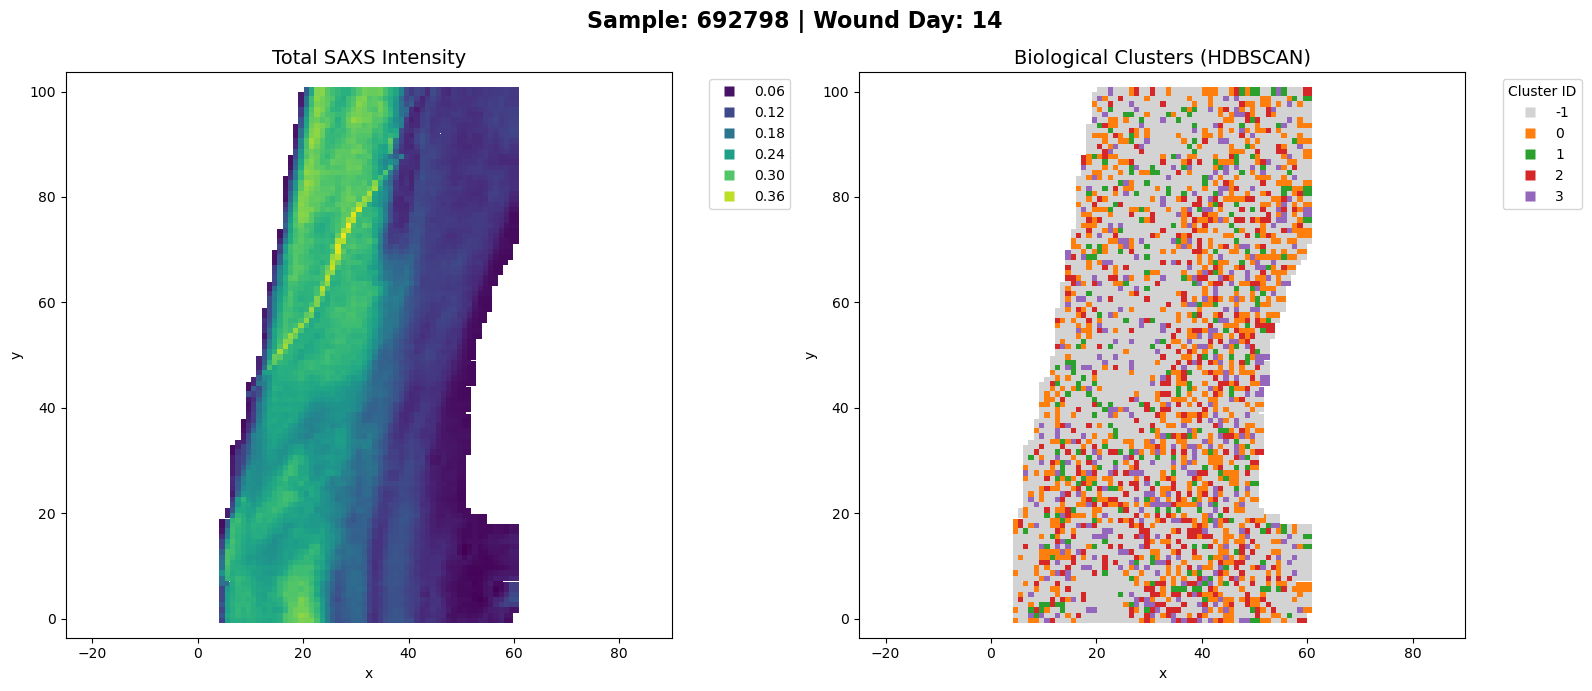

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a custom color palette for the clusters
# We want Noise (-1) to be light grey, and the real clusters to be vibrant colors
unique_clusters = sorted(df_clustering['cluster'].unique())
cluster_colors = {}
color_palette = sns.color_palette("tab10", len(unique_clusters)) # Vibrant distinct colors

for i, cluster_id in enumerate(unique_clusters):
    if cluster_id == -1:
        cluster_colors[cluster_id] = '#d3d3d3' # Light grey for noise
    else:
        cluster_colors[cluster_id] = color_palette[i]

# 2. Get the list of all unique samples
all_samples = df_clustering['sample_id'].unique()

print(f"Generating mapping plots for {len(all_samples)} samples...\n")

# 3. Loop through every single sample and plot it side-by-side
for sample in all_samples:
    # Isolate just the data for this specific sample
    df_single = df_clustering[df_clustering['sample_id'] == sample]
    day = df_single['wound_day'].iloc[0]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f"Sample: {sample} | Wound Day: {day}", fontsize=16, fontweight='bold')
    
    # --- LEFT PLOT: Raw SAXS Intensity ---
    sns.scatterplot(
        data=df_single, x='x', y='y', 
        hue='total SAXS intensity', palette='viridis', 
        edgecolor='none', s=45, marker='s', ax=axes[0]
    )
    axes[0].set_title('Total SAXS Intensity', fontsize=14)
    axes[0].axis('equal')
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # --- RIGHT PLOT: HDBSCAN Clusters ---
    sns.scatterplot(
        data=df_single, x='x', y='y', 
        hue='cluster', palette=cluster_colors, 
        edgecolor='none', s=45, marker='s', ax=axes[1],
        legend='full'
    )
    axes[1].set_title('Biological Clusters (HDBSCAN)', fontsize=14)
    axes[1].axis('equal')
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Cluster ID")
    
    plt.tight_layout()
    plt.show() # Displays them one under the other beautifully in your notebook